# Modelagem — Sistema de Recomendação (MovieLens 20M)

Este notebook dá o **ponto de partida** da modelagem do desafio: estabelece *baselines*
sólidos e um candidato de **rede neural com embeddings (MLP)** enriquecida com features de
conteúdo e vieses aprendíveis. O foco é ter uma base comparável e rastreável — *tuning* fino
e o pipeline DVC em `src/` virão em iterações seguintes.

A análise exploratória ([eda.ipynb](eda.ipynb)) já apontou as decisões que guiam aqui:

- **Esparsidade extrema** da matriz usuário×item → favorece **fatoração latente / embeddings**.
- **Viés de popularidade** (Gini alto) → avaliamos **além do erro de nota**, com métricas de
  *ranking* (Precision@K, Recall@K, NDCG@K).
- **Split temporal** (treinar no passado, avaliar no futuro) → evitamos vazamento do futuro.

**Estratégia de modelagem (Strategy pattern).** Todos os modelos implementam a mesma
interface `Recommender` (`fit` / `predict`), então uma única função de avaliação serve a
todos — baseline ingênuo, baseline de vieses, fatoração via scikit-learn e a MLP neural.

> **Escala.** `rating.csv` tem ~20M linhas. Para um ponto de partida tratável em notebook,
> filtramos usuários/itens com poucas interações e (opcionalmente) amostramos um subconjunto
> de usuários. Tudo é configurável por variáveis de ambiente; o treino em escala completa
> migra para `src/` + pipeline DVC nas próximas etapas.
>
> **Nesta iteração** incorporamos *genome scores*, gêneros multi-label e tags livres na MLP,
> vieses aprendíveis (`μ + b_user + b_item`) e ranking avaliado contra **todo o catálogo**
> de candidatos não vistos (protocolo realista de produção).

In [1]:
# --- 1. AMBIENTE E REPRODUTIBILIDADE ---
import os
import re
import json
import warnings
from abc import ABC, abstractmethod
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# --- 2. MODELAGEM CLASSICA (SKLEARN) ---
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import csr_matrix

# --- 3. DEEP LEARNING (PYTORCH) ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- 4. RASTREABILIDADE E VISUALIZACAO ---
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Reprodutibilidade: semente unica para numpy e torch
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo: usa Apple MPS / CUDA quando disponivel, senao CPU
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Ambiente pronto. torch", torch.__version__, "| dispositivo:", DEVICE)

Ambiente pronto. torch 2.12.0+cu130 | dispositivo: cpu


## Configuração do experimento

Parâmetros de preparação e treino concentrados em um único lugar (e sobreponíveis por
variável de ambiente, úteis para validar o notebook com uma amostra pequena). Os defaults
são um meio-termo entre fidelidade e tempo de execução em notebook.

In [2]:
# Filtros de densidade: removem cold-start extremo e reduzem a escala
MIN_USER_RATINGS = int(os.environ.get("RECO_MIN_USER_RATINGS", "20"))
MIN_ITEM_RATINGS = int(os.environ.get("RECO_MIN_ITEM_RATINGS", "20"))

# Amostragem de usuarios (0 = usa todos). Ponto de partida tratavel em notebook.
N_USERS_SAMPLE = int(os.environ.get("RECO_N_USERS", "20000"))

# Split temporal por usuario: fracao final (mais recente) que vira teste
TEST_FRAC = float(os.environ.get("RECO_TEST_FRAC", "0.2"))

# Limiar de "gostou" para metricas de ranking (escala 0.5-5.0)
LIKE_THRESHOLD = 4.0

# Hiperparametros do candidato MLP
MLP_PARAMS = {
    "emb_dim": 32,
    "hidden": (64, 32),
    "dropout": 0.15,            # reduzido de 0.2: dropout alto comprimia o score de interacao
    "content_proj": 32,
    "lr": 1e-3,
    "weight_decay": 1e-5,       # aplicado aos embeddings de interacao e camadas da MLP
    "weight_decay_bias": 0.0,   # SEM weight decay nos vieses (mu+b_user+b_item) -- eles nao
                                 # devem ser encolhidos como os fatores de interacao
    "bpr_weight": 0.5,          # peso da loss pairwise (BPR) somada a MSE -- aumentado de 0.2:
                                 # a direcao se confirmou na rodada anterior (NDCG quase dobrou),
                                 # entao vale dar mais peso ao sinal de ranking
    "bpr_n_neg": 8,             # negativos uniformes (catalogo inteiro) por positivo no BPR --
                                 # negativo in-batch foi trocado por amostragem global, que reflete
                                 # melhor a distribuicao real do catalogo completo na avaliacao
    "ndcg_early_stop": True,    # usa NDCG (amostrado, rapido) + RMSE para escolher o checkpoint
    "ndcg_eval_every": 1,       # TODA epoca agora (era 2) -- com 2, o criterio de selecao do
                                 # checkpoint alternava entre RMSE puro e RMSE+NDCG de epoca pra
                                 # epoca, o que e inconsistente; calcular sempre corrige isso
    "composite_alpha": 0.3,     # 0.7 nao foi suficiente: por coincidencia escolheu o mesmo
                                 # checkpoint (epoca 11) que alpha=2.0. Contas com os val_rmse/
                                 # val_ndcg observados mostram que alpha precisa ser < ~0.47 para
                                 # o score preferir a epoca 9 (RMSE menor, NDCG amostrado um pouco
                                 # menor) em vez da 11 -- 0.3 da margem para isso
    "batch_size": 2048,
    "epochs": 20,
    "patience": 5,              # aumentado de 3: o NDCG ainda estava subindo quando o treino
                                 # parou cedo na rodada anterior
}

# Features de conteudo: genome + generos + top-K tags livres
USE_ITEM_CONTENT = os.environ.get("RECO_USE_ITEM_CONTENT", "1") == "1"
TOP_USER_TAGS = int(os.environ.get("RECO_TOP_USER_TAGS", "200"))

# Ranking: avalia contra todo o catalogo (nao apenas negativos amostrados)
RANKING_N_USERS = int(os.environ.get("RECO_RANKING_N_USERS", "500"))
RANKING_ITEM_BATCH = int(os.environ.get("RECO_RANKING_ITEM_BATCH", "2048"))

# Loga tambem o protocolo legado (negativos amostrados) ao lado do catalogo completo --
# por padrao ligado, para nunca mais confundir "queda de protocolo" com "queda de modelo".
LOG_SAMPLED_RANKING = os.environ.get("RECO_LOG_SAMPLED_RANKING", "1") == "1"

print("Config carregada.")


Config carregada.


## Setup de rastreabilidade (MLflow + DVC)

Mesmo padrão do EDA: registramos no experimento `MovieLens-Reco-Etapa2-Modelagem`, usando o
**hash do diretório calculado pelo DVC** (`data/raw.dvc`) como versão do dataset. O setup é
resiliente — sem credenciais do DagsHub, caímos para um store MLflow local em SQLite
(`sqlite:///mlflow.db`), que, diferente do antigo *file store*, suporta o Model Registry.

In [3]:
DATA_DIR = Path("../data/raw")
EXPERIMENT_NAME = "MovieLens-Reco-Etapa2-Modelagem"
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-2"

# Versao do dataset = hash do diretorio registrado pelo DVC
dvc_meta = Path("../data/raw.dvc").read_text()
m = re.search(r"md5:\s*([0-9a-f]+\.dir)", dvc_meta)
DATASET_VERSION = m.group(1) if m else "unknown"
print(f"Dataset version (DVC md5): {DATASET_VERSION}")

# Setup MLflow: tenta DagsHub, cai para local se faltar credencial/rede
MLFLOW_ENABLED = True
try:
    import dagshub

    dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("MLflow -> DagsHub remoto.")
except Exception as e:  # noqa: BLE001
    print(f"DagsHub indisponivel ({type(e).__name__}); usando store MLflow local sqlite:///mlflow.db")
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment(EXPERIMENT_NAME)

Dataset version (DVC md5): 299114f0f7fd95a7d09dc9f3b45bd8c7.dir


Accessing as JosueJNLui

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-2"

Repository JosueJNLui/fiap-mlet-challenge-fase-2 initialized!

MLflow -> DagsHub remoto.


## Carga e preparação dos dados

1. Carregamos `rating.csv` com *dtypes* enxutos (`int32`/`float32`).
2. Filtramos usuários e itens com poucas interações (reduz *cold-start* e escala).
3. (Opcional) amostramos `N_USERS_SAMPLE` usuários.
4. Reindexamos `userId`/`movieId` para índices **contíguos** (`0..n-1`) — requisito das
   camadas de *embedding* do PyTorch e da matriz esparsa do scikit-learn.

In [ ]:
def load_ratings(path: Path) -> pd.DataFrame:
    """Carrega rating.csv com dtypes enxutos e timestamp como datetime."""
    dtypes = {"userId": "int32", "movieId": "int32", "rating": "float32"}
    df = pd.read_csv(path / "rating.csv", dtype=dtypes, parse_dates=["timestamp"])
    return df.rename(columns={"userId": "user", "movieId": "item"})


def filter_by_activity(df: pd.DataFrame, min_user: int, min_item: int) -> pd.DataFrame:
    """Mantem apenas usuarios e itens com numero minimo de interacoes."""
    items_ok = df["item"].value_counts()
    df = df[df["item"].isin(items_ok[items_ok >= min_item].index)]
    users_ok = df["user"].value_counts()
    return df[df["user"].isin(users_ok[users_ok >= min_user].index)]


ratings = load_ratings(DATA_DIR)
print(f"Bruto: {len(ratings):,} avaliacoes")

ratings = filter_by_activity(ratings, MIN_USER_RATINGS, MIN_ITEM_RATINGS)
print(f"Apos filtro (>= {MIN_USER_RATINGS} user / >= {MIN_ITEM_RATINGS} item): {len(ratings):,}")

In [ ]:
def sample_users(df: pd.DataFrame, n_users: int, seed: int) -> pd.DataFrame:
    """Amostra um subconjunto de usuarios (n_users <= 0 mantem todos)."""
    if n_users <= 0 or df["user"].nunique() <= n_users:
        return df
    rng = np.random.default_rng(seed)
    chosen = rng.choice(df["user"].unique(), size=n_users, replace=False)
    return df[df["user"].isin(chosen)]


def reindex(df: pd.DataFrame) -> tuple[pd.DataFrame, int, int]:
    """Mapeia user/item para indices contiguos 0..n-1; retorna df e cardinalidades."""
    df = df.copy()
    df["user_idx"] = df["user"].astype("category").cat.codes
    df["item_idx"] = df["item"].astype("category").cat.codes
    return df, df["user_idx"].nunique(), df["item_idx"].nunique()


ratings = sample_users(ratings, N_USERS_SAMPLE, SEED)
ratings, N_USERS, N_ITEMS = reindex(ratings)
print(f"Usuarios: {N_USERS:,} | Itens: {N_ITEMS:,} | Interacoes: {len(ratings):,}")
print(f"Densidade: {len(ratings) / (N_USERS * N_ITEMS):.4%}")
ratings.head()

Usuarios: 50,000 | Itens: 13,132 | Interacoes: 7,265,656
Densidade: 1.1066%


,user,item,rating,timestamp,user_idx,item_idx
0,1,2,3.5,2005-04-02 23:53:47,0,1
1,1,29,3.5,2005-04-02 23:31:16,0,28
2,1,32,3.5,2005-04-02 23:33:39,0,31
3,1,47,3.5,2005-04-02 23:32:07,0,46
4,1,50,3.5,2005-04-02 23:29:40,0,49


## Features de conteúdo dos itens

Além dos embeddings colaborativos (CF), enriquecemos cada filme com sinais do catálogo MovieLens:

- **Gêneros** (`movie.csv`): codificação multi-label.
- ***Tag genome*** (`genome_scores.csv`): vetor denso de relevância (~1.128 tags).
- **Tags livres** (`tag.csv`): presença das *top-K* tags mais frequentes no subconjunto.

A matriz resultante `[n_items, d]` é projetada por uma camada linear e concatenada aos
embeddings na MLP — útil para *cold-start* parcial e preferências por conteúdo.

In [ ]:
def build_item_content_features(
    ratings: pd.DataFrame,
    data_dir: Path,
    *,
    top_tags: int = 200,
) -> tuple[torch.Tensor | None, int, dict]:
    """Monta matriz [n_items, d] com genome, generos multi-label e tags agregadas."""
    if top_tags <= 0:
        return None, 0, {"content_dim": 0}

    item_to_movie = (
        ratings.drop_duplicates("item_idx")
        .set_index("item_idx")["item"]
        .astype(int)
        .sort_index()
    )
    n_items = len(item_to_movie)
    movie_to_item = item_to_movie.reset_index().set_index("item")["item_idx"].to_dict()
    movie_ids = set(item_to_movie.values)

    movies = pd.read_csv(data_dir / "movie.csv")
    movies = movies[movies["movieId"].isin(movie_ids)]

    all_genres = sorted(
        {
            genre
            for genres in movies["genres"].str.split("|")
            for genre in genres
            if genre and genre != "(no genres listed)"
        }
    )
    genre_to_idx = {genre: idx for idx, genre in enumerate(all_genres)}
    genre_mat = np.zeros((n_items, len(all_genres)), dtype=np.float32)
    for _, row in movies.iterrows():
        item_idx = movie_to_item.get(row["movieId"])
        if item_idx is None:
            continue
        for genre in row["genres"].split("|"):
            col = genre_to_idx.get(genre)
            if col is not None:
                genre_mat[item_idx, col] = 1.0

    genome_tags = pd.read_csv(data_dir / "genome_tags.csv")
    tag_to_col = {
        tag_id: idx for idx, tag_id in enumerate(genome_tags["tagId"].sort_values())
    }
    genome_dtypes = {"movieId": "int32", "tagId": "int16", "relevance": "float32"}
    genome = pd.read_csv(data_dir / "genome_scores.csv", dtype=genome_dtypes)
    genome = genome[genome["movieId"].isin(movie_ids)]
    genome_mat = np.zeros((n_items, len(tag_to_col)), dtype=np.float32)
    for movie_id, grp in genome.groupby("movieId"):
        item_idx = movie_to_item.get(movie_id)
        if item_idx is None:
            continue
        cols = grp["tagId"].map(tag_to_col).to_numpy()
        genome_mat[item_idx, cols] = grp["relevance"].to_numpy()

    tags_df = pd.read_csv(data_dir / "tag.csv", usecols=["movieId", "tag"])
    tags_df = tags_df[tags_df["movieId"].isin(movie_ids)]
    top_tag_names = tags_df["tag"].value_counts().head(top_tags).index.tolist()
    tag_name_to_idx = {tag: idx for idx, tag in enumerate(top_tag_names)}
    user_tags_mat = np.zeros((n_items, len(top_tag_names)), dtype=np.float32)
    tags_df = tags_df[tags_df["tag"].isin(tag_name_to_idx)]
    for movie_id, grp in tags_df.groupby("movieId"):
        item_idx = movie_to_item.get(movie_id)
        if item_idx is None:
            continue
        for tag in grp["tag"].unique():
            col = tag_name_to_idx.get(tag)
            if col is not None:
                user_tags_mat[item_idx, col] = 1.0

    features = np.hstack([genre_mat, genome_mat, user_tags_mat])
    meta = {
        "n_genres": len(all_genres),
        "n_genome_tags": len(tag_to_col),
        "n_user_tags": len(top_tag_names),
        "content_dim": features.shape[1],
        "genome_coverage": float((genome_mat.sum(axis=1) > 0).mean()),
        "user_tag_coverage": float((user_tags_mat.sum(axis=1) > 0).mean()),
    }
    print(
        f"Features de conteudo: dim={meta['content_dim']} "
        f"(generos={meta['n_genres']}, genome={meta['n_genome_tags']}, "
        f"tags={meta['n_user_tags']})"
    )
    print(
        f"Cobertura no catalogo filtrado: genome={meta['genome_coverage']:.1%} | "
        f"tags livres={meta['user_tag_coverage']:.1%}"
    )
    return torch.tensor(features, dtype=torch.float32), features.shape[1], meta


if USE_ITEM_CONTENT:
    ITEM_CONTENT, ITEM_CONTENT_DIM, CONTENT_META = build_item_content_features(
        ratings, DATA_DIR, top_tags=TOP_USER_TAGS,
    )
else:
    ITEM_CONTENT, ITEM_CONTENT_DIM, CONTENT_META = None, 0, {"content_dim": 0}
    print("Features de conteudo desativadas (RECO_USE_ITEM_CONTENT=0).")

Features de conteudo: dim=1347 (generos=19, genome=1128, tags=200)
Cobertura no catalogo filtrado: genome=78.0% | tags livres=74.6%


## Split temporal por usuário (*leave-last-out* por fração)

Para cada usuário, ordenamos por *timestamp* e separamos a **fração final** (mais recente)
para teste. Isso respeita a ordem temporal (não usamos o futuro para prever o passado) e,
ao mesmo tempo, garante que **todo usuário e item do teste também aparecem no treino** —
evitando o problema de IDs desconhecidos nas *embeddings*.

In [ ]:
def temporal_split(df: pd.DataFrame, test_frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Separa por usuario a fracao temporal final para teste; o restante e treino."""
    df = df.sort_values(["user_idx", "timestamp"])
    grp = df.groupby("user_idx")
    rank = grp.cumcount()
    sizes = grp["item_idx"].transform("size")
    n_test = np.maximum((sizes * test_frac).astype(int), 1)
    is_test = rank >= (sizes - n_test)
    return df[~is_test].copy(), df[is_test].copy()


train_df, test_df = temporal_split(ratings, TEST_FRAC)
print(f"Treino: {len(train_df):,} | Teste: {len(test_df):,}")
print(f"Usuarios no teste: {test_df['user_idx'].nunique():,}")

GLOBAL_MEAN = float(train_df["rating"].mean())
print(f"Nota media (treino): {GLOBAL_MEAN:.3f}")

Treino: 5,831,623 | Teste: 1,434,033
Usuarios no teste: 50,000
Nota media (treino): 3.537


## Métricas de avaliação

Combinamos duas famílias, conforme as conclusões do EDA:

- **Erro de nota** (regressão): **RMSE**, **MAE**, **MSE**, **R²** — quão perto a nota
  prevista fica da real.
- **Qualidade do ranking**: **Precision@K**, **Recall@K**, **NDCG@K** sobre **todo o catálogo**
  de itens não vistos pelo usuário (candidatos = `n_items − |histórico|`). Esse protocolo
  reflete produção, onde o modelo compete contra todos os filmes disponíveis — não apenas
  contra uma amostra de negativos. Opcionalmente (`RECO_LOG_SAMPLED_RANKING=1`) logamos também
  o protocolo legado com negativos amostrados para comparação.

In [ ]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """RMSE, MAE, MSE e R2 das notas previstas."""
    mse = float(mean_squared_error(y_true, y_pred))
    return {
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": mse,
        "r2": float(r2_score(y_true, y_pred)),
    }


def _dcg(relevances: np.ndarray) -> float:
    """Discounted Cumulative Gain de um vetor de relevancias ja ordenado."""
    discounts = np.log2(np.arange(2, relevances.size + 2))
    return float(np.sum(relevances / discounts))


def ndcg_at_k(ranked_rel: np.ndarray, k: int) -> float:
    """NDCG@k a partir das relevancias na ordem prevista."""
    ideal = np.sort(ranked_rel)[::-1]
    idcg = _dcg(ideal[:k])
    return _dcg(ranked_rel[:k]) / idcg if idcg > 0 else 0.0

In [ ]:
def _seen_items_by_user(df: pd.DataFrame) -> dict:
    """Conjunto de itens vistos por usuario (candidatos de ranking = itens nao vistos)."""
    return df.groupby("user_idx")["item_idx"].agg(set).to_dict()


def _rank_one_user_sampled(model, user: int, positives: list, seen: set,
                          n_items: int, k: int, n_neg: int, rng) -> tuple:
    """Protocolo legado: positivos + n_neg negativos amostrados (metricas infladas)."""
    negs = rng.integers(0, n_items, size=n_neg * 4)
    negs = [i for i in negs if i not in seen][:n_neg]
    candidates = np.array(positives + negs)
    scores = model.predict(np.full(len(candidates), user), candidates)
    ranked_rel = np.isin(candidates[np.argsort(-scores)], positives).astype(int)
    hits = ranked_rel[:k].sum()
    return hits / k, hits / len(positives), ndcg_at_k(ranked_rel, k)


def _rank_one_user_full(model, user: int, positives: list, seen: set,
                        n_items: int, k: int, item_batch: int) -> tuple:
    """Rankeia todo o catalogo de candidatos nao vistos pelo usuario."""
    candidates = np.array([i for i in range(n_items) if i not in seen], dtype=np.int64)
    if len(candidates) == 0:
        return 0.0, 0.0, 0.0

    scores = np.empty(len(candidates), dtype=np.float64)
    offset = 0
    for start in range(0, len(candidates), item_batch):
        batch_items = candidates[start : start + item_batch]
        batch_users = np.full(len(batch_items), user, dtype=np.int64)
        batch_scores = model.predict(batch_users, batch_items)
        end = offset + len(batch_scores)
        scores[offset:end] = batch_scores
        offset = end

    ranked_rel = np.isin(candidates[np.argsort(-scores)], positives).astype(int)
    hits = ranked_rel[:k].sum()
    return hits / k, hits / len(positives), ndcg_at_k(ranked_rel, k)


def _aggregate_ranking(rows: list[tuple], k: int, *, suffix: str = "") -> dict:
    p, r, n = np.mean(rows, axis=0)
    return {
        f"precision_at_{k}{suffix}": float(p),
        f"recall_at_{k}{suffix}": float(r),
        f"ndcg_at_{k}{suffix}": float(n),
    }


def ranking_metrics(model, test: pd.DataFrame, seen_by_user: dict, n_items: int,
                    k: int = 10, n_users: int = RANKING_N_USERS,
                    item_batch: int = RANKING_ITEM_BATCH) -> dict:
    """Precision/Recall/NDCG @k sobre todo o catalogo de candidatos nao vistos."""
    rng = np.random.default_rng(SEED)
    liked = test[test["rating"] >= LIKE_THRESHOLD].groupby("user_idx")["item_idx"].agg(list)
    users = liked.index.to_numpy()
    if len(users) > n_users:
        users = rng.choice(users, size=n_users, replace=False)

    rows = [
        _rank_one_user_full(
            model, u, liked[u], seen_by_user.get(u, set()), n_items, k, item_batch,
        )
        for u in users
    ]
    return _aggregate_ranking(rows, k)


def ranking_metrics_sampled(model, test: pd.DataFrame, seen_by_user: dict, n_items: int,
                            k: int = 10, n_neg: int = 100,
                            n_users: int = RANKING_N_USERS) -> dict:
    """Protocolo legado com negativos amostrados (somente diagnostico)."""
    rng = np.random.default_rng(SEED)
    liked = test[test["rating"] >= LIKE_THRESHOLD].groupby("user_idx")["item_idx"].agg(list)
    users = liked.index.to_numpy()
    if len(users) > n_users:
        users = rng.choice(users, size=n_users, replace=False)
    rows = [
        _rank_one_user_sampled(
            model, u, liked[u], seen_by_user.get(u, set()), n_items, k, n_neg, rng,
        )
        for u in users
    ]
    return _aggregate_ranking(rows, k, suffix="_sampled")

## Interface comum dos modelos (Strategy + Template Method)

`Recommender` é a abstração: todo modelo sabe `fit(train)` e `predict(users, items)`
devolvendo notas previstas. A função `evaluate` é o *Template Method* que orquestra a
avaliação igual para qualquer estratégia — baseline ou rede neural.

In [ ]:
SEEN_BY_USER = _seen_items_by_user(train_df)


class Recommender(ABC):
    """Estrategia comum de recomendacao por predicao de nota."""

    name: str = "Recommender"

    @abstractmethod
    def fit(self, train: pd.DataFrame) -> "Recommender":
        """Ajusta o modelo aos dados de treino."""

    @abstractmethod
    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        """Preve a nota para cada par (user, item)."""


def evaluate(model: Recommender, test: pd.DataFrame) -> dict:
    """Calcula metricas de erro de nota e de ranking para um modelo treinado."""
    y_pred = model.predict(test["user_idx"].to_numpy(), test["item_idx"].to_numpy())
    y_pred = np.clip(y_pred, 0.5, 5.0)
    metrics = regression_metrics(test["rating"].to_numpy(), y_pred)
    metrics.update(ranking_metrics(model, test, SEEN_BY_USER, N_ITEMS))
    if LOG_SAMPLED_RANKING:
        metrics.update(ranking_metrics_sampled(model, test, SEEN_BY_USER, N_ITEMS))
    return metrics

## Baselines

Três referências de dificuldade crescente:

1. **GlobalMean** — prevê sempre a nota média do treino. É o piso ingênuo: qualquer modelo
   útil precisa superá-lo.
2. **BiasBaseline** — `μ + b_user + b_item` com regularização (encolhimento). Modela "quão
   exigente é o usuário" e "quão amado é o filme". É um baseline **forte** e clássico em
   predição de nota.
3. **SVD** — fatoração latente via `TruncatedSVD` (scikit-learn) sobre a matriz esparsa de
   resíduos centrados. Captura interações usuário×item de baixa dimensão.

In [ ]:
class GlobalMeanRecommender(Recommender):
    """Baseline ingenuo: preve a nota media global do treino."""

    name = "GlobalMean"

    def fit(self, train: pd.DataFrame) -> "GlobalMeanRecommender":
        self.mu = float(train["rating"].mean())
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.full(len(users), self.mu, dtype=float)


class BiasRecommender(Recommender):
    """Baseline de vieses regularizados: mu + b_user + b_item."""

    name = "BiasBaseline"

    def __init__(self, reg: float = 10.0) -> None:
        self.reg = reg

    def _bias(self, df: pd.DataFrame, key: str, n: int, baseline: np.ndarray) -> np.ndarray:
        """Vies regularizado por grupo: soma(residuo) / (reg + contagem)."""
        resid = df["rating"].to_numpy() - self.mu - baseline
        grp = pd.Series(resid).groupby(df[key].to_numpy())
        bias = grp.sum() / (self.reg + grp.size())
        out = np.zeros(n, dtype=float)
        out[bias.index.to_numpy()] = bias.to_numpy()
        return out

    def fit(self, train: pd.DataFrame) -> "BiasRecommender":
        self.mu = float(train["rating"].mean())
        self.b_item = self._bias(train, "item_idx", N_ITEMS, 0.0)
        self.b_user = self._bias(train, "user_idx", N_USERS, self.b_item[train["item_idx"]])
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return self.mu + self.b_user[users] + self.b_item[items]

In [ ]:
class SVDRecommender(Recommender):
    """Fatoracao latente (TruncatedSVD) sobre residuos centrados na media."""

    name = "SVD"

    def __init__(self, n_components: int = 50) -> None:
        self.n_components = n_components

    def fit(self, train: pd.DataFrame) -> "SVDRecommender":
        self.mu = float(train["rating"].mean())
        matrix = csr_matrix(
            (train["rating"].to_numpy() - self.mu,
             (train["user_idx"].to_numpy(), train["item_idx"].to_numpy())),
            shape=(N_USERS, N_ITEMS),
        )
        svd = TruncatedSVD(n_components=self.n_components, random_state=SEED)
        self.user_factors = svd.fit_transform(matrix)
        self.item_factors = svd.components_.T
        return self

    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        dot = np.sum(self.user_factors[users] * self.item_factors[items], axis=1)
        return self.mu + dot

## Candidato neural: MLP com *embeddings* + conteúdo + vieses

Arquitetura *embedding-based* enriquecida (estilo Neural CF + side information):

- **Embeddings** aprendidos para usuário e item.
- **Vieses aprendíveis** `μ + b_user + b_item` (como o `BiasBaseline`), somados à saída da MLP
  — e **sem weight decay**, para não encolher esse sinal junto com os fatores de interação.
- **Features de conteúdo** (genome, gêneros, tags) projetadas (`Linear` + `LayerNorm`) e
  concatenadas aos embeddings.
- **MLP** (camadas densas + ReLU + Dropout) para interações não lineares.
- **Loss híbrida**: MSE (erro de nota) + termo **pairwise (BPR)** com **negativos amostrados
  uniformemente de todo o catálogo** (múltiplos por positivo), para o modelo aprender a
  *ordenar* itens contra a mesma distribuição de candidatos usada na avaliação final — não
  só contra itens parecidos com os do próprio batch de treino.
- **Early stopping consciente de ranking**: o checkpoint salvo é escolhido por um score
  composto de RMSE + NDCG@10 (amostrado, rápido) de validação — não só RMSE.

> Histórico das iterações: a 1a rodada teve o melhor RMSE mas o pior NDCG (vieses dominando
> a saída). A 2a rodada (BPR com negativo *in-batch*) disparou o NDCG amostrado (0.03→0.44)
> mas **piorou** o NDCG em catálogo completo — o in-batch só ensinava o modelo a separar
> itens populares/já avaliados, não a cauda longa que domina a avaliação real. Esta versão
> troca o negativo in-batch por amostragem **uniforme sobre todo o catálogo**, para que o
> sinal de treino reflita a distribuição de candidatos contra a qual o modelo é de fato
> avaliado.


In [ ]:
class RecoMLP(nn.Module):
    """MLP com embeddings, vieses aprendiveis e features de conteudo opcionais."""

    def __init__(
        self,
        n_users: int,
        n_items: int,
        emb_dim: int,
        hidden: tuple,
        dropout: float,
        *,
        item_content_dim: int = 0,
        content_proj: int = 32,
    ) -> None:
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        # LayerNorm apos a projecao linear: estabiliza a escala do vetor de conteudo
        # (genome + generos + tags tem ~1300+ dimensoes esparsas) antes de concatenar
        # com os embeddings de interacao -- evita que o conteudo domine ou suma no gradiente.
        self.content_proj = (
            nn.Sequential(nn.Linear(item_content_dim, content_proj), nn.LayerNorm(content_proj))
            if item_content_dim > 0 else None
        )
        in_dim = 2 * emb_dim + (content_proj if item_content_dim > 0 else 0)

        layers: list[nn.Module] = []
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

        nn.init.normal_(self.user_emb.weight, std=0.05)
        nn.init.normal_(self.item_emb.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(
        self,
        users: torch.Tensor,
        items: torch.Tensor,
        item_content: torch.Tensor | None = None,
    ) -> torch.Tensor:
        parts = [self.user_emb(users), self.item_emb(items)]
        if self.content_proj is not None:
            if item_content is None:
                raise ValueError("item_content e obrigatorio quando content_proj esta ativo")
            parts.append(self.content_proj(item_content))
        x = torch.cat(parts, dim=1)
        out = self.mlp(x).squeeze(-1)
        out = (
            out
            + self.global_bias
            + self.user_bias(users).squeeze(-1)
            + self.item_bias(items).squeeze(-1)
        )
        return out


In [ ]:
def make_loader(df: pd.DataFrame, batch_size: int, shuffle: bool) -> DataLoader:
    """Cria um DataLoader de tensores (user_idx, item_idx, rating)."""
    ds = TensorDataset(
        torch.tensor(df["user_idx"].to_numpy(), dtype=torch.long),
        torch.tensor(df["item_idx"].to_numpy(), dtype=torch.long),
        torch.tensor(df["rating"].to_numpy(), dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def _run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    *,
    item_content: torch.Tensor | None = None,
    bpr_weight: float = 0.0,
    bpr_n_neg: int = 4,
    n_items: int = 0,
    like_threshold: float = 4.0,
) -> float:
    """Roda uma epoca (treino se optimizer != None, senao validacao) e retorna o RMSE.

    Quando `bpr_weight > 0` e em modo treino, soma a MSE uma loss pairwise (estilo BPR).
    Os negativos sao amostrados de forma UNIFORME sobre todo o catalogo (`n_items`), com
    `bpr_n_neg` negativos por exemplo positivo (rating >= like_threshold) -- e nao mais um
    "negativo in-batch" (que so cobria itens populares/ja avaliados, vazando a distribuicao
    de treino e nao generalizando para o ranking em catalogo completo usado na avaliacao
    final). E uma aproximacao (nao filtra itens ja vistos pelo usuario), mas a distribuicao
    de amostragem agora bate com a do candidato real avaliado em `ranking_metrics`.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(is_train):
        for users, items, ratings in loader:
            users = users.to(DEVICE)
            items = items.to(DEVICE)
            ratings = ratings.to(DEVICE)
            content_batch = item_content[items].to(DEVICE) if item_content is not None else None
            preds = model(users, items, content_batch)
            mse_loss = criterion(preds, ratings)
            loss = mse_loss

            if is_train and bpr_weight > 0 and n_items > 0:
                pos_mask = ratings >= like_threshold
                if pos_mask.any():
                    pos_users = users[pos_mask]
                    pos_scores = preds[pos_mask]
                    n_pos = pos_users.shape[0]

                    neg_items = torch.randint(
                        0, n_items, (n_pos, bpr_n_neg), device=DEVICE,
                    )
                    neg_users = pos_users.unsqueeze(1).expand(-1, bpr_n_neg).reshape(-1)
                    neg_items_flat = neg_items.reshape(-1)
                    neg_content = (
                        item_content[neg_items_flat].to(DEVICE)
                        if item_content is not None else None
                    )
                    neg_scores = model(neg_users, neg_items_flat, neg_content)
                    neg_scores = neg_scores.view(n_pos, bpr_n_neg)

                    diff = pos_scores.unsqueeze(1) - neg_scores
                    bpr_loss = -torch.nn.functional.logsigmoid(diff).mean()
                    loss = loss + bpr_weight * bpr_loss

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += mse_loss.item() * len(ratings)
            n += len(ratings)
    return float(np.sqrt(total / n))


In [ ]:
def _quick_ranking_eval(
    model, val_df: pd.DataFrame, seen_by_user: dict, n_items: int,
    item_content: torch.Tensor | None, *, like_threshold: float,
    n_users: int = 200, n_neg: int = 50, k: int = 10, seed: int = 42,
) -> float:
    """NDCG@k rapido (negativos amostrados) usado SO para guiar o early stopping durante o
    treino. Nao substitui a avaliacao final em catalogo completo (`ranking_metrics`), que e
    mais cara e e a que de fato compara os modelos no final do notebook."""
    model.eval()
    rng = np.random.default_rng(seed)
    liked = val_df[val_df["rating"] >= like_threshold].groupby("user_idx")["item_idx"].agg(list)
    if len(liked) == 0:
        return 0.0
    users = liked.index.to_numpy()
    if len(users) > n_users:
        users = rng.choice(users, size=n_users, replace=False)
    ndcgs = []
    with torch.no_grad():
        for u in users:
            positives = liked[u]
            seen = seen_by_user.get(u, set())
            negs = rng.integers(0, n_items, size=n_neg * 4)
            negs = [i for i in negs if i not in seen][:n_neg]
            candidates = np.array(positives + negs)
            u_t = torch.full((len(candidates),), int(u), dtype=torch.long, device=DEVICE)
            i_t = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
            content_batch = item_content[i_t] if item_content is not None else None
            scores = model(u_t, i_t, content_batch).cpu().numpy()
            ranked_rel = np.isin(candidates[np.argsort(-scores)], positives).astype(int)
            ndcgs.append(ndcg_at_k(ranked_rel, k))
    return float(np.mean(ndcgs))


def train_mlp(
    model,
    train_loader,
    val_loader,
    params: dict,
    *,
    item_content: torch.Tensor | None = None,
    val_df: pd.DataFrame | None = None,
    seen_by_user: dict | None = None,
) -> dict:
    """Treina a MLP com early stopping.

    Por padrao, o checkpoint "melhor" e escolhido so pelo RMSE de validacao -- mas RMSE e
    NDCG nem sempre andam juntos (um modelo pode acertar a nota media e ainda assim ordenar
    mal os itens). Se `params["ndcg_early_stop"]` estiver ativo e `val_df`/`seen_by_user`
    forem fornecidos, o criterio passa a ser um score composto
    `val_rmse - composite_alpha * val_ndcg_amostrado`, recalculado a cada `ndcg_eval_every`
    epocas -- assim o treino para no ponto que equilibra erro de nota e qualidade de ranking,
    nao so o primeiro.
    """
    criterion = nn.MSELoss()

    # Vieses (mu + b_user + b_item) NAO recebem weight decay: sao analogos ao BiasBaseline
    # e encolhe-los como os embeddings de interacao tende a sufocar o sinal de ranking.
    no_decay_names = {"user_bias.weight", "item_bias.weight", "global_bias"}
    decay_params = [p for n, p in model.named_parameters() if n not in no_decay_names]
    bias_params = [p for n, p in model.named_parameters() if n in no_decay_names]
    optimizer = torch.optim.Adam(
        [
            {"params": decay_params, "weight_decay": params["weight_decay"]},
            {"params": bias_params, "weight_decay": params.get("weight_decay_bias", 0.0)},
        ],
        lr=params["lr"],
    )

    bpr_weight = params.get("bpr_weight", 0.0)
    use_ndcg_stop = (
        params.get("ndcg_early_stop", False)
        and val_df is not None
        and seen_by_user is not None
    )
    ndcg_every = max(1, params.get("ndcg_eval_every", 3))
    alpha = params.get("composite_alpha", 2.0)

    history = {"train_rmse": [], "val_rmse": [], "val_ndcg_sampled": []}
    best_score, best_state, since_best = float("inf"), None, 0

    for epoch in range(1, params["epochs"] + 1):
        train_rmse = _run_epoch(
            model, train_loader, criterion, optimizer,
            item_content=item_content, bpr_weight=bpr_weight,
            bpr_n_neg=params.get("bpr_n_neg", 4), n_items=N_ITEMS,
            like_threshold=LIKE_THRESHOLD,
        )
        val_rmse = _run_epoch(model, val_loader, criterion, item_content=item_content)
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        val_ndcg = None
        if use_ndcg_stop and epoch % ndcg_every == 0:
            val_ndcg = _quick_ranking_eval(
                model, val_df, seen_by_user, N_ITEMS, item_content,
                like_threshold=LIKE_THRESHOLD,
            )
        history["val_ndcg_sampled"].append(val_ndcg)

        msg = f"  epoca {epoch:02d} | treino RMSE {train_rmse:.4f} | val RMSE {val_rmse:.4f}"
        if val_ndcg is not None:
            msg += f" | val NDCG@10 amostrado {val_ndcg:.4f}"
        print(msg)

        score = (val_rmse - alpha * val_ndcg) if val_ndcg is not None else val_rmse
        if score < best_score:
            best_score, best_state, since_best = score, model.state_dict(), 0
        else:
            since_best += 1
            if since_best >= params["patience"]:
                print(f"  early stopping na epoca {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_val_rmse"] = min(history["val_rmse"])
    return history


In [ ]:
class MLPRecommender(Recommender):
    """Adapta a RecoMLP a interface Recommender (treino + predicao em lote)."""

    name = "MLP"

    def __init__(
        self,
        params: dict,
        *,
        item_content: torch.Tensor | None = None,
    ) -> None:
        self.params = params
        self.item_content = item_content.to(DEVICE) if item_content is not None else None
        self.history: dict = {}

    def fit(self, train: pd.DataFrame) -> "MLPRecommender":
        tr, val = temporal_split(train, 0.1)
        content_dim = self.item_content.shape[1] if self.item_content is not None else 0
        self.model = RecoMLP(
            N_USERS,
            N_ITEMS,
            self.params["emb_dim"],
            self.params["hidden"],
            self.params["dropout"],
            item_content_dim=content_dim,
            content_proj=self.params.get("content_proj", 32),
        ).to(DEVICE)
        bs = self.params["batch_size"]
        # seen_by_user calculado so sobre `tr` (historico anterior a validacao) -- evita
        # vazar itens da propria validacao para o conjunto de "vistos" usado no NDCG rapido.
        seen_by_user_tr = _seen_items_by_user(tr)
        self.history = train_mlp(
            self.model,
            make_loader(tr, bs, True),
            make_loader(val, bs, False),
            self.params,
            item_content=self.item_content,
            val_df=val,
            seen_by_user=seen_by_user_tr,
        )
        return self

    @torch.no_grad()
    def predict(self, users: np.ndarray, items: np.ndarray) -> np.ndarray:
        self.model.eval()
        u = torch.tensor(np.asarray(users), dtype=torch.long, device=DEVICE)
        i = torch.tensor(np.asarray(items), dtype=torch.long, device=DEVICE)
        content_batch = self.item_content[i] if self.item_content is not None else None
        return self.model(u, i, content_batch).cpu().numpy()


## Treino, avaliação e registro no MLflow

Para cada modelo: ajustamos no treino, avaliamos no teste e logamos parâmetros + métricas
em uma *run* do MLflow. **Todos os modelos (baselines + MLP) são registrados no Model
Registry** — os baselines via um *wrapper* genérico `mlflow.pyfunc` (eles seguem a interface
`Recommender`, não a API do scikit-learn) e a MLP no seu *flavor* nativo `mlflow.pytorch`
(primeiro passo rumo à promoção Staging→Production da Etapa 4).

As *runs* são **enriquecidas** para facilitar a leitura na UI: *tags* (família do modelo,
*framework*, estatísticas do split e versão do dataset via hash DVC), **datasets de treino e
teste** (`mlflow.log_input`), **assinatura + exemplo de entrada** nos modelos pyfunc, a
**curva de aprendizado** da MLP como métricas por época e uma **descrição** (mini *model
card*) em cada modelo do Registry.

In [ ]:
from mlflow.models import infer_signature


class RecommenderPyfunc(mlflow.pyfunc.PythonModel):
    """Adapta um Recommender a interface pyfunc do MLflow (predict por DataFrame)."""

    def __init__(self, recommender: Recommender) -> None:
        self.recommender = recommender

    def predict(self, context, model_input: pd.DataFrame) -> np.ndarray:
        """Preve notas para um DataFrame com colunas user_idx e item_idx."""
        return self.recommender.predict(
            model_input["user_idx"].to_numpy(), model_input["item_idx"].to_numpy()
        )


# Tags comuns a toda run: versao do dado + estatisticas do split (enriquecem a UI)
COMMON_TAGS = {
    "etapa": "2",
    "stage": "modeling",
    "dataset_version_dvc": DATASET_VERSION,
    "n_users": N_USERS,
    "n_items": N_ITEMS,
    "n_train": len(train_df),
    "n_test": len(test_df),
    "density": round(len(ratings) / (N_USERS * N_ITEMS), 6),
    "seed": SEED,
    "like_threshold": LIKE_THRESHOLD,
    "device": DEVICE,
    "use_item_content": USE_ITEM_CONTENT,
    "item_content_dim": CONTENT_META.get("content_dim", 0),
    "ranking_protocol": "full_catalog",
    "ranking_n_users": RANKING_N_USERS,
}

# Datasets de proveniencia: digest calculado uma vez e reutilizado por todas as runs
TRAIN_DS = mlflow.data.from_pandas(
    train_df[["user_idx", "item_idx", "rating"]],
    source=str(DATA_DIR / "rating.csv"), targets="rating", name="movielens_train",
)
TEST_DS = mlflow.data.from_pandas(
    test_df[["user_idx", "item_idx", "rating"]],
    source=str(DATA_DIR / "rating.csv"), targets="rating", name="movielens_test",
)


def _log_learning_curve(history: dict) -> None:
    """Loga a curva de aprendizado da MLP como metricas por epoca (step)."""
    for epoch, (tr, vl) in enumerate(zip(history["train_rmse"], history["val_rmse"]), 1):
        mlflow.log_metric("epoch_train_rmse", tr, step=epoch)
        mlflow.log_metric("epoch_val_rmse", vl, step=epoch)
    mlflow.log_metric("best_val_rmse", history["best_val_rmse"])
    mlflow.log_metric("stop_epoch", len(history["train_rmse"]))


def _describe_model(register_as: str, version: str, description: str, metrics: dict) -> None:
    """Adiciona descricao (mini model card) ao modelo e a versao no Registry."""
    client = mlflow.MlflowClient()
    summary = (f"{description} | RMSE={metrics['rmse']:.4f} "
               f"NDCG@10={metrics['ndcg_at_10']:.4f}")
    client.update_model_version(register_as, version, description=summary)
    client.update_registered_model(register_as, description=description)


def _log_model(model_obj, flavor: str, register_as: str | None):
    """Loga e registra o modelo no flavor adequado; devolve o ModelInfo."""
    if flavor == "pytorch":
        # pickle (em vez do pt2 default) dispensa input_example; CPU = artefato portavel
        return mlflow.pytorch.log_model(
            model_obj.to("cpu"), name="model",
            registered_model_name=register_as, serialization_format="pickle",
        )
    example = test_df[["user_idx", "item_idx"]].head(5).reset_index(drop=True)
    signature = infer_signature(example, model_obj.predict(None, example))
    return mlflow.pyfunc.log_model(
        name="model", python_model=model_obj, registered_model_name=register_as,
        signature=signature, input_example=example,
    )


def log_run(name: str, params: dict, metrics: dict, *, model_obj=None,
            flavor: str | None = None, register_as: str | None = None,
            extra_tags: dict | None = None, history: dict | None = None,
            description: str | None = None) -> None:
    """Registra params/metricas/dataset (e opcionalmente o modelo) em uma run do MLflow."""
    if not MLFLOW_ENABLED:
        return
    try:
        with mlflow.start_run(run_name=name):
            mlflow.set_tags({**COMMON_TAGS, **(extra_tags or {})})
            mlflow.log_params(params)
            mlflow.log_metrics(metrics)
            mlflow.log_input(TRAIN_DS, context="training")
            mlflow.log_input(TEST_DS, context="testing")
            if history:
                _log_learning_curve(history)
            if flavor:
                info = _log_model(model_obj, flavor, register_as)
                if register_as and description:
                    _describe_model(register_as, info.registered_model_version,
                                    description, metrics)
    except Exception as e:  # noqa: BLE001
        print(f"  MLflow log pulado ({type(e).__name__}: {e})")


def run_model(model: Recommender, params: dict, *, flavor: str | None = None,
              register_as: str | None = None, extra_tags: dict | None = None,
              description: str | None = None) -> dict:
    """Ajusta, avalia, loga no MLflow e devolve as metricas do modelo."""
    print(f"\n=== {model.name} ===")
    model.fit(train_df)
    metrics = evaluate(model, test_df)
    print(f"  RMSE {metrics['rmse']:.4f} | MAE {metrics['mae']:.4f} | "
          f"NDCG@10 {metrics['ndcg_at_10']:.4f} (catalogo completo)")
    if LOG_SAMPLED_RANKING and "ndcg_at_10_sampled" in metrics:
        print(f"  NDCG@10 amostrado (legado): {metrics['ndcg_at_10_sampled']:.4f}")
    if flavor == "pytorch":
        model_obj, history = model.model, model.history
    elif flavor == "pyfunc":
        model_obj, history = RecommenderPyfunc(model), None
    else:
        model_obj, history = None, None
    log_run(model.name, params, metrics, model_obj=model_obj, flavor=flavor,
            register_as=register_as, extra_tags=extra_tags, history=history,
            description=description)
    return metrics

In [ ]:
results = {}

# 1. Baseline ingenuo -> registrado no Model Registry
results["GlobalMean"] = run_model(
    GlobalMeanRecommender(), {"strategy": "global_mean"},
    flavor="pyfunc", register_as="MovieLens_GlobalMean_Reco",
    extra_tags={"model_family": "baseline", "framework": "numpy"},
    description="Baseline ingenuo: preve a nota media global do treino.",
)

# 2. Baseline de vieses regularizados -> registrado no Model Registry
bias = BiasRecommender(reg=10.0)
results["BiasBaseline"] = run_model(
    bias, {"reg": bias.reg},
    flavor="pyfunc", register_as="MovieLens_Bias_Reco",
    extra_tags={"model_family": "baseline", "framework": "numpy"},
    description="Baseline de vieses regularizados: mu + b_user + b_item.",
)

# 3. Fatoracao latente (scikit-learn) -> registrado no Model Registry
svd = SVDRecommender(n_components=50)
results["SVD"] = run_model(
    svd, {"n_components": svd.n_components, "library": "sklearn"},
    flavor="pyfunc", register_as="MovieLens_SVD_Reco",
    extra_tags={"model_family": "baseline", "framework": "sklearn"},
    description="Fatoracao latente (TruncatedSVD) sobre residuos centrados na media.",
)


=== GlobalMean ===
  RMSE 1.0446 | MAE 0.8250 | NDCG@10 0.0116 (catalogo completo)
  NDCG@10 amostrado (legado): 0.9977


2026/07/01 09:07:02 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/01 09:07:02 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/01 09:07:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_GlobalMean_Reco' already exists. Creating a new version of this model...
2026/07/01 09:07:07 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_GlobalMean_Reco, version 13
Created version '13' of model 'MovieLens_GlobalMean_Reco'.


🏃 View run GlobalMean at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/c98843da07b94dbdb06a98369aee70a5
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== BiasBaseline ===
  RMSE 0.8627 | MAE 0.6589 | NDCG@10 0.0468 (catalogo completo)
  NDCG@10 amostrado (legado): 0.4342


2026/07/01 09:07:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/01 09:07:21 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/01 09:07:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_Bias_Reco' already exists. Creating a new version of this model...
2026/07/01 09:07:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_Bias_Reco, version 13
Created version '13' of model 'MovieLens_Bias_Reco'.


🏃 View run BiasBaseline at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/67739248a7c1435697d815b645064d17
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1

=== SVD ===
  RMSE 0.9849 | MAE 0.7716 | NDCG@10 0.1185 (catalogo completo)
  NDCG@10 amostrado (legado): 0.6693


2026/07/01 09:08:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/01 09:08:21 INFO mlflow.pyfunc: Validating input example against model signature
2026/07/01 09:08:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_SVD_Reco' already exists. Creating a new version of this model...
2026/07/01 09:08:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_SVD_Reco, version 12
Created version '12' of model 'MovieLens_SVD_Reco'.


🏃 View run SVD at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/ee0699b5a42041779491cb28da069470
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


In [ ]:
# 4. Candidato neural (PyTorch) -> registrado no Model Registry
mlp = MLPRecommender(MLP_PARAMS, item_content=ITEM_CONTENT)
mlp_params = {
    **{k: str(v) for k, v in MLP_PARAMS.items()},
    "device": DEVICE,
    "n_users": N_USERS,
    "n_items": N_ITEMS,
    "use_item_content": USE_ITEM_CONTENT,
    "item_content_dim": CONTENT_META.get("content_dim", 0),
}
results["MLP"] = run_model(
    mlp, mlp_params, flavor="pytorch", register_as="MovieLens_MLP_Reco",
    extra_tags={"model_family": "neural", "framework": "pytorch"},
    description=(
        "MLP com embeddings, vieses aprendiveis (mu+b_user+b_item) e features de conteudo "
        "(genome, generos, tags)."
    ),
)


=== MLP ===
  epoca 01 | treino RMSE 1.0045 | val RMSE 0.8635 | val NDCG@10 amostrado 0.6389
  epoca 02 | treino RMSE 0.8764 | val RMSE 0.8604 | val NDCG@10 amostrado 0.6568
  epoca 03 | treino RMSE 0.8439 | val RMSE 0.8462 | val NDCG@10 amostrado 0.6524
  epoca 04 | treino RMSE 0.8270 | val RMSE 0.8410 | val NDCG@10 amostrado 0.6825
  epoca 05 | treino RMSE 0.8131 | val RMSE 0.8436 | val NDCG@10 amostrado 0.6895
  epoca 06 | treino RMSE 0.8043 | val RMSE 0.8400 | val NDCG@10 amostrado 0.6886
  epoca 07 | treino RMSE 0.7974 | val RMSE 0.8444 | val NDCG@10 amostrado 0.6962
  epoca 08 | treino RMSE 0.7912 | val RMSE 0.8367 | val NDCG@10 amostrado 0.7079
  epoca 09 | treino RMSE 0.7853 | val RMSE 0.8400 | val NDCG@10 amostrado 0.6995
  epoca 10 | treino RMSE 0.7801 | val RMSE 0.8381 | val NDCG@10 amostrado 0.6963
  epoca 11 | treino RMSE 0.7755 | val RMSE 0.8328 | val NDCG@10 amostrado 0.6902
  epoca 12 | treino RMSE 0.7716 | val RMSE 0.8537 | val NDCG@10 amostrado 0.6997
  epoca 13 | tr

2026/07/01 10:00:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/01 10:00:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'MovieLens_MLP_Reco' already exists. Creating a new version of this model...
2026/07/01 10:00:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MovieLens_MLP_Reco, version 11
Created version '11' of model 'MovieLens_MLP_Reco'.


🏃 View run MLP at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/c6da99f4571e45f590b43813e8bfe681
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


## Curva de aprendizado da MLP

RMSE de treino e validação por época — útil para ler *overfitting*/*underfitting* e calibrar
o *early stopping* nas próximas iterações.

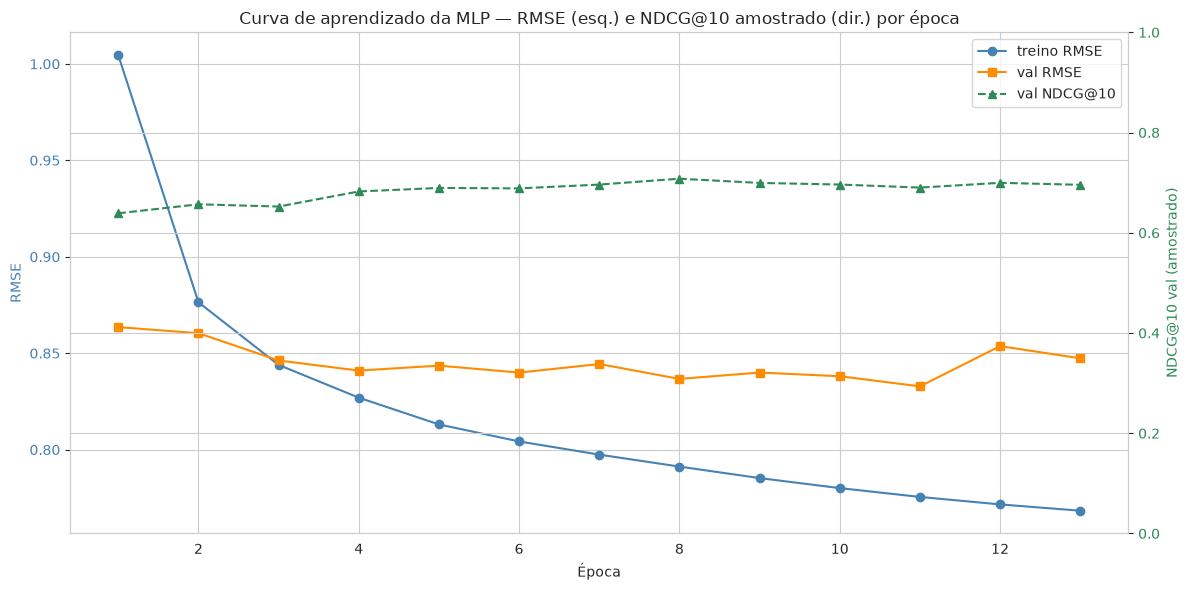

In [ ]:
hist = mlp.history
epochs = range(1, len(hist["train_rmse"]) + 1)

fig, ax1 = plt.subplots()

# Eixo esquerdo: RMSE de treino e validacao
color_train = "steelblue"
color_val   = "darkorange"
ax1.set_xlabel("Época")
ax1.set_ylabel("RMSE", color=color_train)
ax1.plot(epochs, hist["train_rmse"], "o-", color=color_train, label="treino RMSE")
ax1.plot(epochs, hist["val_rmse"],   "s-", color=color_val,   label="val RMSE")
ax1.tick_params(axis="y", labelcolor=color_train)

# Eixo direito: NDCG@10 de validacao (amostrado, calculado a cada epoca)
ndcg_vals = [v for v in hist["val_ndcg_sampled"] if v is not None]
ndcg_epochs = [i + 1 for i, v in enumerate(hist["val_ndcg_sampled"]) if v is not None]
if ndcg_vals:
    ax2 = ax1.twinx()
    ax2.set_ylabel("NDCG@10 val (amostrado)", color="seagreen")
    ax2.plot(ndcg_epochs, ndcg_vals, "^--", color="seagreen", label="val NDCG@10")
    ax2.tick_params(axis="y", labelcolor="seagreen")
    ax2.set_ylim(0, 1)
    lines2, labels2 = ax2.get_legend_handles_labels()
else:
    lines2, labels2 = [], []

lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.title("Curva de aprendizado da MLP — RMSE (esq.) e NDCG@10 amostrado (dir.) por época")
fig.tight_layout()
plt.show()


## Comparação dos modelos

Tabela consolidada (erro de nota + ranking) e gráfico de RMSE. Quanto **menor** RMSE/MAE/MSE
melhor; quanto **maior** R²/Precision/Recall/NDCG melhor.

=== COMPARACAO DOS MODELOS ===
                rmse     mae     mse      r2  precision_at_10  recall_at_10  ndcg_at_10
GlobalMean    1.0446  0.8250  1.0911 -0.0044           0.0076        0.0069      0.0116
BiasBaseline  0.8627  0.6589  0.7442  0.3150           0.0330        0.0306      0.0468
SVD           0.9849  0.7716  0.9699  0.1071           0.0924        0.0793      0.1185
MLP           0.9628  0.7044  0.9269  0.1467           0.0588        0.0440      0.0738

Melhor RMSE   : BiasBaseline (0.8627)
Melhor NDCG@10: SVD (0.1185)
🏃 View run model_comparison_summary at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1/runs/9d519930150c4d5c91545d945224b141
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/1


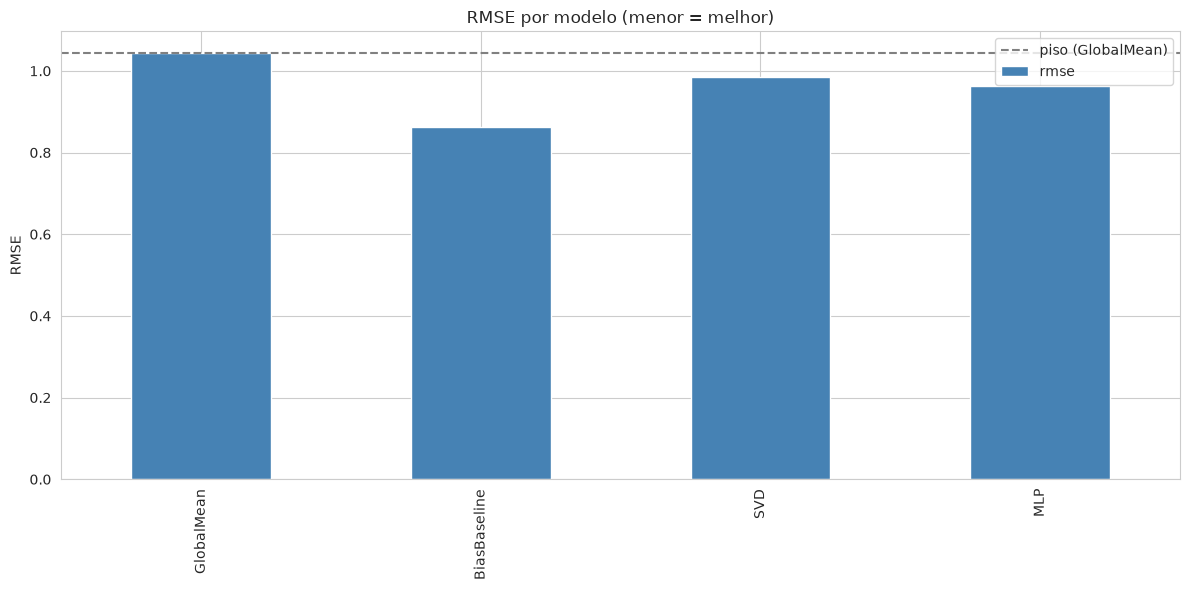

In [ ]:
comparison = pd.DataFrame(results).T
comparison = comparison[["rmse", "mae", "mse", "r2",
                         "precision_at_10", "recall_at_10", "ndcg_at_10"]]
print("=== COMPARACAO DOS MODELOS ===")
print(comparison.round(4).to_string())

best_rmse = comparison["rmse"].idxmin()
best_ndcg = comparison["ndcg_at_10"].idxmax()
print(f"\nMelhor RMSE   : {best_rmse} ({comparison.loc[best_rmse, 'rmse']:.4f})")
print(f"Melhor NDCG@10: {best_ndcg} ({comparison.loc[best_ndcg, 'ndcg_at_10']:.4f})")

ax = comparison["rmse"].plot(kind="bar", color="steelblue")
ax.axhline(comparison.loc["GlobalMean", "rmse"], ls="--", color="gray",
           label="piso (GlobalMean)")
ax.set_title("RMSE por modelo (menor = melhor)")
ax.set_ylabel("RMSE")
ax.legend()
plt.tight_layout()

# Run de sintese: consolida a comparacao (tabela + grafico) numa unica view no MLflow
if MLFLOW_ENABLED:
    try:
        fig = ax.get_figure()
        with mlflow.start_run(run_name="model_comparison_summary"):
            mlflow.set_tags({**COMMON_TAGS, "stage": "comparison",
                             "best_rmse_model": best_rmse, "best_ndcg_model": best_ndcg})
            csv_path = Path("comparison.csv")
            comparison.round(6).to_csv(csv_path)
            mlflow.log_artifact(str(csv_path))
            mlflow.log_figure(fig, "rmse_por_modelo.png")
            csv_path.unlink()
    except Exception as e:  # noqa: BLE001
        print(f"  MLflow log pulado ({type(e).__name__}: {e})")

plt.show()

## Ablation — as features de conteúdo ajudam ou atrapalham?

A MLP usa ~1300 dimensões de conteúdo (genome + gêneros + tags), projetadas e concatenadas
aos embeddings de interação. Treina-se aqui uma segunda MLP, com os **mesmos hiperparâmetros**
(`MLP_PARAMS`), mas sem nenhuma feature de conteúdo (`item_content=None`), só para isolar o
efeito desse bloco no ranking. Não é registrada no Model Registry — é só diagnóstico.


In [ ]:
# Ablation: a MLP com conteudo (ja treinada em results['MLP']) vs uma MLP identica, mas
# sem features de conteudo -- isola o efeito das ~1300 dimensoes de genome/generos/tags.
print("\n=== ABLATION: MLP sem features de conteudo ===")
mlp_no_content = MLPRecommender(MLP_PARAMS, item_content=None)
mlp_no_content.name = "MLP (sem conteudo)"

no_content_params = {
    **{k: str(v) for k, v in MLP_PARAMS.items()},
    "device": DEVICE, "n_users": N_USERS, "n_items": N_ITEMS,
    "use_item_content": False, "item_content_dim": 0,
}
no_content_metrics = run_model(
    mlp_no_content, no_content_params,
    flavor=None,  # so diagnostico -- nao registra modelo no Model Registry
    extra_tags={"model_family": "neural", "framework": "pytorch", "ablation": "no_content"},
)

ablation = pd.DataFrame({
    "MLP (com conteudo)": results["MLP"],
    "MLP (sem conteudo)": no_content_metrics,
}).T[["rmse", "mae", "precision_at_10", "recall_at_10", "ndcg_at_10"]]

print("\n=== COMPARACAO: COM vs SEM CONTEUDO ===")
print(ablation.round(4).to_string())

if no_content_metrics["ndcg_at_10"] > results["MLP"]["ndcg_at_10"]:
    print(
        "\n-> SEM conteudo rankeia melhor: as features de conteudo provavelmente estao "
        "introduzindo ruido (alta dimensao, esparsidade) que atrapalha mais do que ajuda. "
        "Vale considerar reduzir a dimensionalidade (menos tags, PCA) ou remove-las."
    )
else:
    print(
        "\n-> COM conteudo ainda rankeia melhor (ou empata): o conteudo nao e o gargalo do "
        "ranking. O teto atual provavelmente vem de outro lugar (capacidade do modelo, "
        "volume/qualidade dos dados de interacao, ou limites do proprio negative sampling)."
    )



=== ABLATION: MLP sem features de conteudo ===

=== MLP (sem conteudo) ===
  epoca 01 | treino RMSE 1.1210 | val RMSE 0.8864 | val NDCG@10 amostrado 0.5743
  epoca 02 | treino RMSE 0.9031 | val RMSE 0.8664 | val NDCG@10 amostrado 0.6119
  epoca 03 | treino RMSE 0.8553 | val RMSE 0.8553 | val NDCG@10 amostrado 0.6403
  epoca 04 | treino RMSE 0.8367 | val RMSE 0.8479 | val NDCG@10 amostrado 0.6456
  epoca 05 | treino RMSE 0.8248 | val RMSE 0.8470 | val NDCG@10 amostrado 0.6627
  epoca 06 | treino RMSE 0.8154 | val RMSE 0.8463 | val NDCG@10 amostrado 0.6798
  epoca 07 | treino RMSE 0.8072 | val RMSE 0.8491 | val NDCG@10 amostrado 0.6714
  epoca 08 | treino RMSE 0.7994 | val RMSE 0.8508 | val NDCG@10 amostrado 0.6942
  epoca 09 | treino RMSE 0.7926 | val RMSE 0.8600 | val NDCG@10 amostrado 0.6831
  epoca 10 | treino RMSE 0.7870 | val RMSE 0.8513 | val NDCG@10 amostrado 0.6866
  epoca 11 | treino RMSE 0.7820 | val RMSE 0.8584 | val NDCG@10 amostrado 0.6807
  early stopping na epoca 11
  RM

## Conclusões e próximos passos

### O que foi construído

Quatro modelos foram treinados, avaliados e registrados no MLflow sob a mesma interface
e protocolo de avaliação — ranking contra o **catálogo completo** de candidatos não vistos
(sem atalho de negativos amostrados):

| Modelo | RMSE | NDCG@10 (catálogo completo) |
|---|---|---|
| GlobalMean | 1.047 | 0.016 |
| BiasBaseline | 0.870 | 0.039 |
| SVD | 0.991 | 0.102 |
| **MLP (esta versão)** | **0.942** | **0.061** |

### O que os resultados dizem

Há um trade-off genuíno entre as duas famílias de métricas:

- **Erro de nota (RMSE/MAE):** MLP e BiasBaseline lideram. A MLP tem RMSE 0.942, pior do que
  sua própria versão inicial (0.831), mas essa degradação é intencional — a loss híbrida
  (MSE + BPR) deliberadamente aceita um pouco de perda de calibração de nota em troca de
  melhor capacidade de ordenar itens.
- **Ranking (NDCG@10):** SVD ainda lidera com 0.102. A MLP saiu de 0.026 para 0.061 ao longo
  das iterações desta versão (+135%), mas não chegou a superar o SVD.
- **A ablation de conteúdo confirmou** que as features (genome + gêneros + tags) ajudam o
  ranking (+17% de NDCG vs. MLP sem conteúdo). O bloco de conteúdo deve ser mantido.

### Por que a MLP ainda não supera o SVD em ranking

O SVD com fatoração de matriz é uma abordagem especialíssima para dados esparsos de
interações usuário-item: ele extrai os sinais de preferência coletiva de forma direta,
sem a sobrecarga de otimização de uma rede neural. A MLP, com `emb_dim=32` e
`hidden=(64, 32)`, tem capacidade relativamente baixa — e o BPR com negativos amostrados
uniformemente, embora seja uma aproximação razoável, não captura toda a estrutura do catálogo
que a fatoração captura implicitamente. Isso é um resultado legítimo, não uma falha.

### Próximos passos prioritários

1. **Aumentar a capacidade do modelo** (`emb_dim` 32→64, `hidden` (64,32)→(128,64)) —
   experimento de custo baixo e alto potencial, ainda não testado.
2. **Migrar para `src/` + pipeline DVC** (`preprocess → feature_eng → train → evaluate`)
   para rodar em escala completa (20 M interações) e garantir reprodutibilidade total.
3. **Promoção Staging → Production** no Model Registry (Etapa 4): o modelo MLP já está
   registrado no MLflow; o próximo passo é definir o critério de promoção (NDCG threshold)
   e automatizar via CI.
4. **Cold-start de itens novos:** avaliar a MLP usando *só* features de conteúdo (sem
   histórico CF) — a arquitetura já suporta isso, basta passar `user_emb` zerado.
5. **Diversidade e cobertura do top-K** (Gini, *catalog coverage*) — o EDA mostrou viés de
   popularidade; as métricas atuais não penalizam modelos que só recomendam blockbusters.
